Here we visualize the predictions of the eomt model trained on Cityscapes for the class of semantic segmentation. 

For testing the notebook use Colab. I run it on my own GPU which is still not enough to keep both models at the same time.
In this case:
### Step 1.
Run semantic inference
### Step 2.
Restart kernel
### Step 3.
Run panoptic inference

In [1]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib

/home/sina/Projects/ElisaMLDL/outlierdrive/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
seed_everything(0, verbose=False)

device = 0  
img_idx = 0 

city_config_path = "../eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
coco_config_path = "../eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"


data_path = "../data/datasets"

trained_city_path = "../eomt_checkpoints/eomt_cityscapes.bin"
trained_coco_path = "../eomt_checkpoints/eomt_coco.bin"

with open(city_config_path, "r") as f:
    city_config = yaml.safe_load(f)

with open(coco_config_path, "r") as f:
    coco_config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image


## Load dataset

We create a helper function in order to load data for two versions of eomt. The images come from the Cityscapes validation set, but the model config changes for Cityscapes vs COCO.

In [3]:
import sys
sys.path.append("../eomt")

In [4]:
def load_data(config, data_path):
    data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
    data_module = getattr(importlib.import_module(data_module_name), class_name)
    data_module_kwargs = config["data"].get("init_args", {})

    return data_module(
        path=data_path,
        batch_size=1,
        num_workers=0,
        check_empty_targets=False,
        **data_module_kwargs
    ).setup()

# download only Cityscapes validation images
# COCO model is used only for inference now
city_data = load_data(city_config, data_path)


## Load model
We need to load the two versions of the eomt model. Write a function that builds the EoMT model architecture from yaml config, and then call this function for different config.
Here the tricky part is that we do not use COCO dataset, only COCO config and COCO checkpoint. The following function does not assume size of images or number of classes. 


In [ ]:
def build_model(config, device, data=None, reference_img_size=None, reference_num_classes=None):

    warnings.filterwarnings(
        "ignore",
        message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
    )

    # data=None for COCO model without loading COCO dataset
    # we provide metadata manually, from config file

    if data is not None:
        img_size = data.img_size
        num_classes = data.num_classes
    else:
        img_size = reference_img_size
        num_classes = reference_num_classes

    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)

    encoder = encoder_cls(
        img_size=img_size,
        **encoder_cfg.get("init_args", {})
    )

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)

    network_kwargs = {
        k: v for k, v in network_cfg["init_args"].items() if k != "encoder"
    }

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)

    model_kwargs = {
        k: v for k, v in config["model"]["init_args"].items() if k != "network"
    }

    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = (
        lit_cls(
            img_size=img_size,
            num_classes=num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    return model

Next, we construct two transformer-based networks. Pay attention that we move both models to GPU memory. Do not load two models at the same time. First, build the Cityscape-trained model, run it, save the resulting images for the report. Then, restart the kernel, release GPU memory and do the same for COCO-trained model.

In [6]:
city_model = build_model(
    city_config,
    device,
    data=city_data
)

In [6]:
coco_model = build_model(
    coco_config,
    device,
    data=None,
    reference_img_size=(640, 640),
    reference_num_classes=133
)

## Load pre-trained weights

In [7]:
def load_weights(model, checkpoint, device):
    weights = torch.load(
        checkpoint,
        map_location=f"cuda:{device}",
        weights_only=False
    )

    if "state_dict" in weights:
        weights = weights["state_dict"]

    model.load_state_dict(weights, strict=False)

    return model

In [8]:
# city_model is only an ARCHITECTURE
# city_model_trained is ARCHITECTURE + WEIGHTS

city_model_trained = load_weights(city_model, trained_city_path, device)

In [8]:
coco_model_trained = load_weights(coco_model, trained_coco_path, device)

## Semantic inference
Only for the Cityscapes-trained model, because Cityscapes task is semantic segmentation.

In [9]:
IGNORE_INDEX = 255

def infer_semantic(img, target, model, data):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()

    return pred_array, target_array

In [10]:
def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        "../data/eomt_pretrained_output/semantic/semantic_img0.png",
        bbox_inches="tight"
    )

    plt.show()

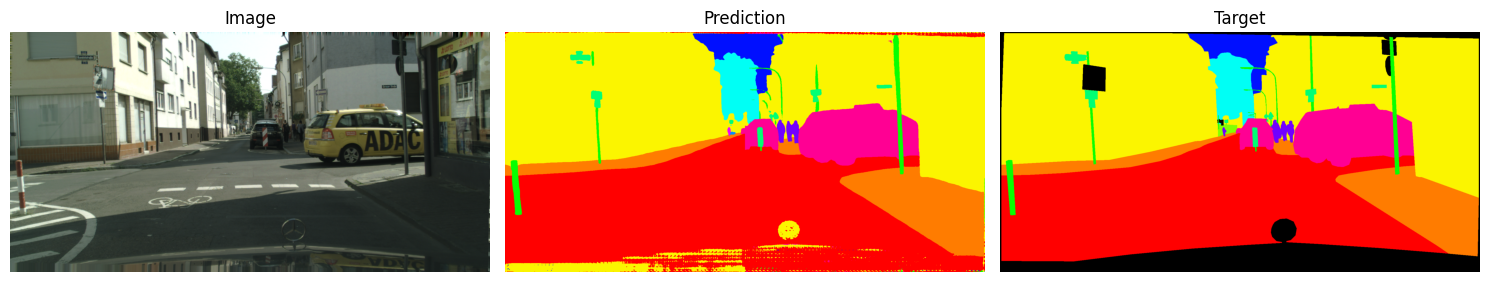

In [11]:
img, target = city_data.val_dataloader().dataset[img_idx]

pred_array, target_array = infer_semantic(
    img,
    target,
    city_model_trained,
    city_data
)

plot_semantic_results(img, pred_array, target_array)

## Panoptic inference
Only for COCO-trained model using a sample from the same Cityscapes validation set. Then we compare both model predictions on the SAME IMAGE.

In [9]:
def infer_panoptic(img, model):
    
    with torch.inference_mode(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )

        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    return sem_pred, inst_pred

In [10]:
def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out

In [11]:
def plot_panoptic_prediction(img, sem_pred, inst_pred, model):
    all_ids = np.unique(sem_pred)

    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)

    img_np = img.cpu().numpy().transpose(1, 2, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("COCO Panoptic Prediction")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()

    plt.savefig(
        f"../data/eomt_pretrained_output/panoptic/panoptic_img0.png",
        bbox_inches="tight"
    )

    plt.show()

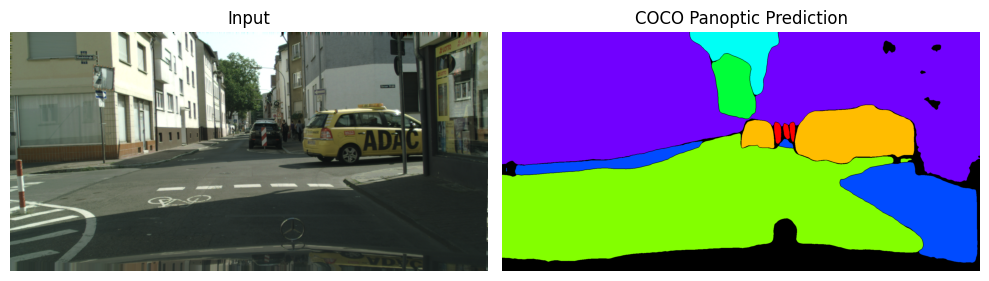

In [12]:
img, _ = city_data.val_dataloader().dataset[img_idx]

sem_pred, inst_pred = infer_panoptic(img, coco_model_trained)
plot_panoptic_prediction(img, sem_pred, inst_pred, coco_model_trained)

Consider the difference how pretrained models behave differently depending on training objective. We use the same architecture but different training task and get different predictions. 
Cityscapes-trained model is trained for semantic segmentation. For example, all cars are treated as one category. COCO-trained model classifies every pixel and separate object instances. We can see that each separate car in the black border implies one instance.